# Financial Sentiment Analysis
## Phase 1: Data Loading & Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load the dataset
df = pd.read_csv('data/raw/data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (5842, 2)
Columns: ['Sentence', 'Sentiment']


In [4]:
# Explore data
print("Sentiment distribution:")
print(df['Sentiment'].value_counts())
print(f"\nClass balance: {df['Sentiment'].value_counts(normalize=True).round(3).to_dict()}")

Sentiment distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

Class balance: {'neutral': 0.536, 'positive': 0.317, 'negative': 0.147}


In [6]:
# Preview sample texts for each sentiment
print("Sample positive sentiment:")
print(df[df['Sentiment'] == 'positive']['Sentence'].iloc[0][:200], "...\n")

print("Sample negative sentiment:")
print(df[df['Sentiment'] == 'negative']['Sentence'].iloc[0][:200], "...\n")

print("Sample neutral sentiment:")
print(df[df['Sentiment'] == 'neutral']['Sentence'].iloc[0][:200], "...")

Sample positive sentiment:
The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful  ...

Sample negative sentiment:
$ESI on lows, down $1.50 to $2.50 BK a real possibility ...

Sample neutral sentiment:
According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia . ...


Retaining stopwords and punctuation is essential for financial text as symbols like $, %, and special patterns reveal sentiment.

In [7]:
# Preprocessing: Lowercase only - keep all punctuation
def preprocess_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower()

df['processed_text'] = df['Sentence'].apply(preprocess_text)

# Convert labels to numeric: positive=2, neutral=1, negative=0
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['Sentiment'].map(sentiment_map)

print("Preprocessing complete!")
print(f"Label mapping: {sentiment_map}")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")

Preprocessing complete!
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Label distribution: {1: 3130, 2: 1852, 0: 860}


## Visualization: Class Distribution

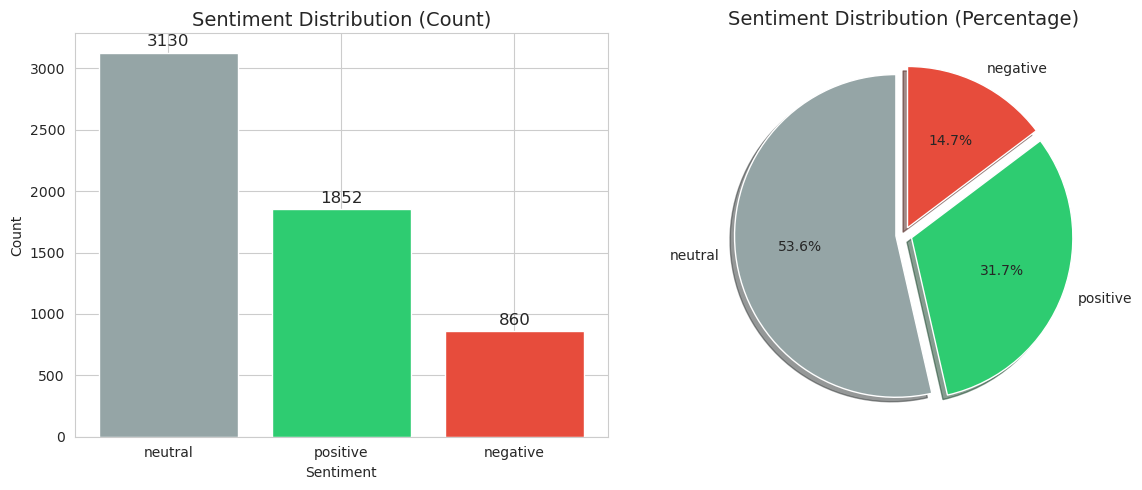

In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_counts = df['Sentiment'].value_counts()
colors = ['#95a5a6', '#2ecc71', '#e74c3c']

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Sentiment Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=colors, explode=(0.05, 0.05, 0.05), shadow=True, startangle=90)
axes[1].set_title('Sentiment Distribution (Percentage)', fontsize=14)

plt.tight_layout()
plt.show()

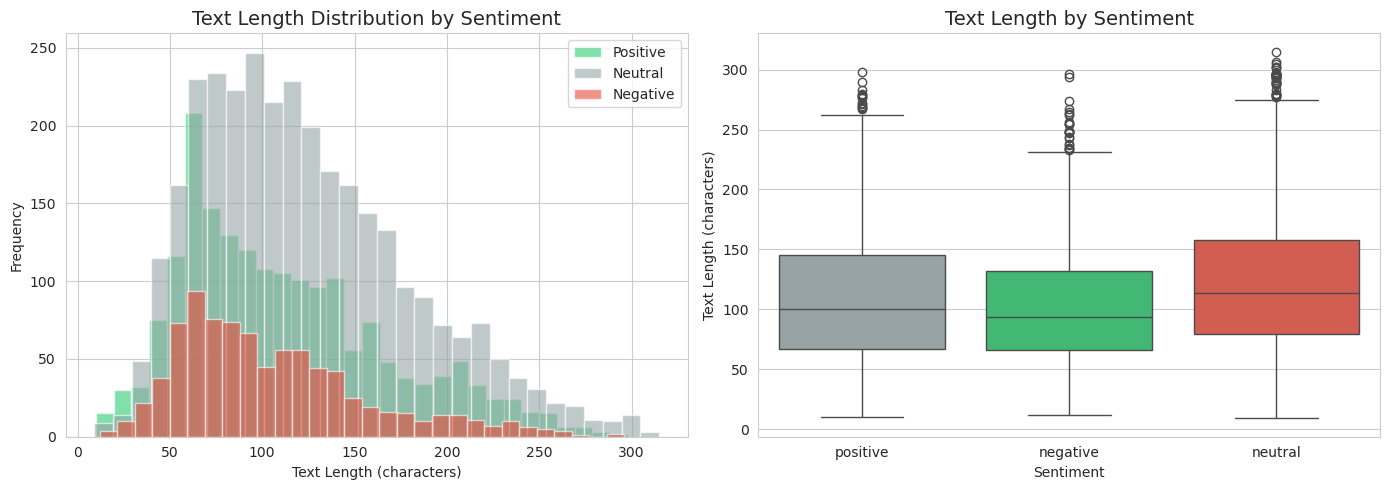


Text Length Stats:
            count        mean        std   min   25%    50%     75%    max
Sentiment                                                                 
negative    860.0  105.330233  51.798956  12.0  66.0   94.0  132.25  296.0
neutral    3130.0  123.113419  56.872104   9.0  79.0  114.0  158.00  315.0
positive   1852.0  112.157127  56.412443  10.0  67.0  100.0  145.25  298.0


In [10]:
# Visualize text length distribution
df['text_length'] = df['Sentence'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment, color, label in [('positive', '#2ecc71', 'Positive'), 
                                  ('neutral', '#95a5a6', 'Neutral'),
                                  ('negative', '#e74c3c', 'Negative')]:
    axes[0].hist(df[df['Sentiment'] == sentiment]['text_length'], bins=30, alpha=0.6, 
                 label=label, color=color)

axes[0].set_title('Text Length Distribution by Sentiment', fontsize=14)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x='Sentiment', y='text_length', data=df, ax=axes[1], 
            hue='Sentiment', palette=colors, legend=False)
axes[1].set_title('Text Length by Sentiment', fontsize=14)
axes[1].set_ylabel('Text Length (characters)')

plt.tight_layout()
plt.show()

print(f"\nText Length Stats:")
print(df.groupby('Sentiment')['text_length'].describe())

In [11]:
# Train/Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining labels: {y_train.value_counts().sort_index().to_dict()}")
print(f"Test labels: {y_test.value_counts().sort_index().to_dict()}")

Training set: 4673 samples
Test set: 1169 samples

Training labels: {0: 688, 1: 2504, 2: 1481}
Test labels: {0: 172, 1: 626, 2: 371}


## Phase 1 Complete! Ready for Phase 2.

## Phase 2: Feature Engineering (TF-IDF)

In [13]:
from collections import Counter
import math

# N-gram Generator: splits text into n-grams
# Example: "the quick brown" with n=2 -> ["the quick", "quick brown"]
def generate_ngrams(text, n):
    words = text.split()
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)
    return ngrams

# Test the function
test_text = "the quick brown fox jumps"
print("Testing n-gram generation:")
print(f"Original: '{test_text}'")
print(f"Bigrams (n=2): {generate_ngrams(test_text, 2)}")
print(f"Trigrams (n=3): {generate_ngrams(test_text, 3)}")

Testing n-gram generation:
Original: 'the quick brown fox jumps'
Bigrams (n=2): ['the quick', 'quick brown', 'brown fox', 'fox jumps']
Trigrams (n=3): ['the quick brown', 'quick brown fox', 'brown fox jumps']


In [14]:
# Build Vocabulary: creates a dictionary of all n-grams in the corpus
# Each n-gram gets a unique index
def build_vocabulary(texts, n):
    vocab = set()
    for text in texts:
        ngrams = generate_ngrams(text, n)
        vocab.update(ngrams)
    return {ng: i for i, ng in enumerate(sorted(vocab))}

# Build vocabulary with unigrams
vocab = build_vocabulary(df['processed_text'], 1)
print(f"Vocabulary size (unigrams): {len(vocab)}")

Vocabulary size (unigrams): 14098


In [16]:
# TF-IDF Vectorizer from scratch
class TFIDFVectorizer:
    """
    TF-IDF (Term Frequency - Inverse Document Frequency)
    
    TF: How often a term appears in a document
    IDF: How rare the term is across all documents (penalizes common words)
    TF-IDF = TF * IDF
    """
    
    def __init__(self, n=1):
        self.n = n
        self.vocabulary_ = {}
        self.idf_ = {}

    def fit(self, texts):
        """Learn vocabulary and IDF scores from texts."""
        # Build vocabulary
        self.vocabulary_ = build_vocabulary(texts, self.n)
        
        # Calculate document frequency for each term
        num_docs = len(texts)
        doc_freq = Counter()
        
        for text in texts:
            # Use set to count each term only once per document
            ngrams = set(generate_ngrams(text, self.n))
            for ng in ngrams:
                if ng in self.vocabulary_:
                    doc_freq[ng] += 1
        
        # Calculate IDF: log(N / df) where N = total docs, df = docs containing term
        self.idf_ = {}
        for term, df in doc_freq.items():
            self.idf_[term] = math.log(num_docs / df)
        
        return self

    def transform(self, texts):
        """Convert texts to TF-IDF vectors."""
        num_terms = len(self.vocabulary_)
        vectors = []
        
        for text in texts:
            # Calculate term frequency
            ngrams = generate_ngrams(text, self.n)
            tf = Counter(ngrams)
            
            # Create TF-IDF vector
            vector = np.zeros(num_terms)
            for term, tf_count in tf.items():
                if term in self.vocabulary_:
                    idx = self.vocabulary_[term]
                    idf = self.idf_.get(term, 0)
                    vector[idx] = tf_count * idf
            
            vectors.append(vector)
        
        return np.array(vectors)

    def fit_transform(self, texts):
        """Fit and transform in one step."""
        self.fit(texts)
        return self.transform(texts)

# Test with unigrams
tfidf = TFIDFVectorizer(n=1)
X_tfidf = tfidf.fit_transform(df['processed_text'])
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Sample vector (first 10 values): {X_tfidf[0][:10]}")

TF-IDF matrix shape: (5842, 14098)
Sample vector (first 10 values): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Phase 2 Visualization: Vocabulary & TF-IDF

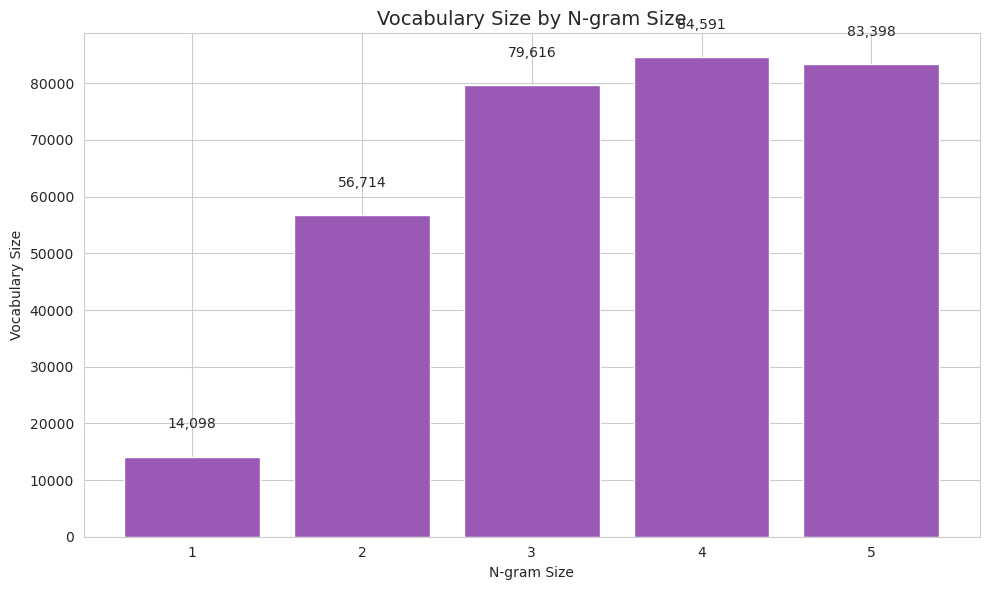


Vocabulary sizes by N-gram:
  1-gram: 14,098 terms
  2-gram: 56,714 terms
  3-gram: 79,616 terms
  4-gram: 84,591 terms
  5-gram: 83,398 terms


In [26]:
# Visualize vocabulary size vs N-gram size (1-5)
vocab_sizes = []
for n in range(1, 6):
    vocab = build_vocabulary(df['processed_text'], n)
    vocab_sizes.append(len(vocab))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), vocab_sizes, color='#9b59b6')
ax.set_title('Vocabulary Size by N-gram Size', fontsize=14)
ax.set_xlabel('N-gram Size')
ax.set_ylabel('Vocabulary Size')
ax.set_xticks(range(1, 6))

for i, v in enumerate(vocab_sizes):
    ax.text(i+1, v + 5000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nVocabulary sizes by N-gram:")
for n, size in enumerate(vocab_sizes, 1):
    print(f"  {n}-gram: {size:,} terms")

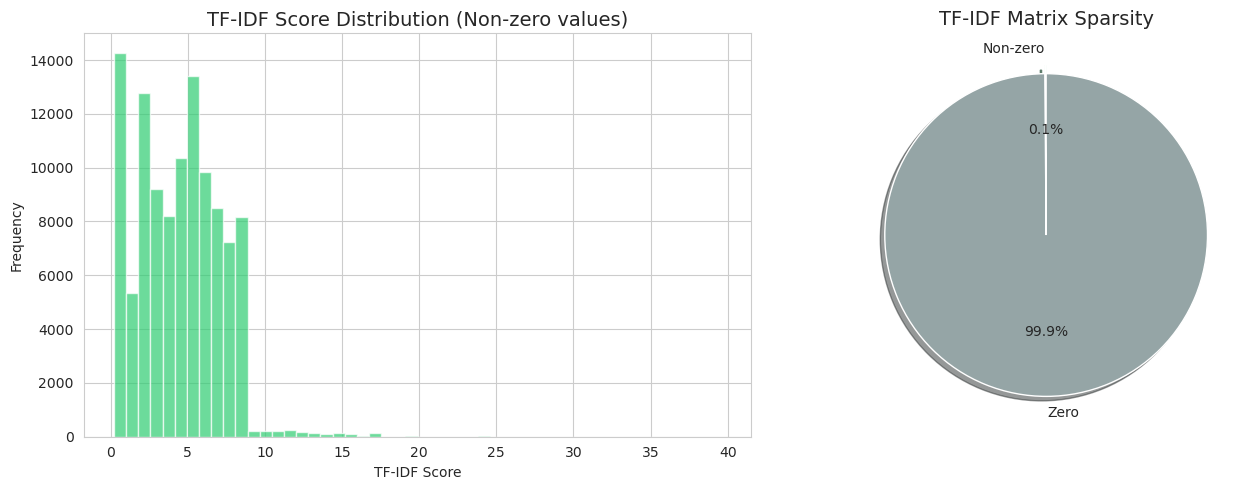


TF-IDF Matrix Info:
  Shape: (5842, 14098)
  Sparsity: 99.9% zeros
  Density: 0.1% non-zero values


In [27]:
# Visualize TF-IDF score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get non-zero TF-IDF values
tfidf_flat = X_tfidf.flatten()
nonzero_tfidf = tfidf_flat[tfidf_flat > 0]

axes[0].hist(nonzero_tfidf, bins=50, color='#2ecc71', alpha=0.7)
axes[0].set_title('TF-IDF Score Distribution (Non-zero values)', fontsize=14)
axes[0].set_xlabel('TF-IDF Score')
axes[0].set_ylabel('Frequency')

# Calculate sparsity
sparsity = (X_tfidf == 0).sum() / X_tfidf.size * 100
density = 100 - sparsity

axes[1].pie([density, sparsity], labels=['Non-zero', 'Zero'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#95a5a6'],
        explode=(0.05, 0), shadow=True, startangle=90)
axes[1].set_title('TF-IDF Matrix Sparsity', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nTF-IDF Matrix Info:")
print(f"  Shape: {X_tfidf.shape}")
print(f"  Sparsity: {sparsity:.1f}% zeros")
print(f"  Density: {density:.1f}% non-zero values")

## Phase 3: Logistic Regression (Multi-class)

In [28]:
# Sigmoid function: squashes values between 0 and 1
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Test sigmoid
print("Sigmoid test:")
print(f"  sigmoid(0) = {sigmoid(0)}")
print(f"  sigmoid(1) = {sigmoid(1):.4f}")
print(f"  sigmoid(-1) = {sigmoid(-1):.4f}")

Sigmoid test:
  sigmoid(0) = 0.5
  sigmoid(1) = 0.7311
  sigmoid(-1) = 0.2689


In [29]:
# Binary Logistic Regression (for One-vs-Rest)
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000, C=0.1):
        self.C = C  # regularization strength
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.n_iterations):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(linear)
            
            # Gradient calculation
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # L1 regularization: adds penalty for large weights
            reg = 1.0 / self.C
            dw += reg * np.sign(self.weights)
            
            # Update weights
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        return sigmoid(np.dot(X, self.weights) + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("LogisticRegression class defined!")

LogisticRegression class defined!


In [30]:
# Multi-class Logistic Regression using One-vs-Rest
class MultiClassLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000, C=0.1):
        self.models = {}
        self.C = C
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
    
    def fit(self, X, y):
        classes = np.unique(y)
        for c in classes:
            # Binary: current class = 1, others = 0
            y_binary = (y == c).astype(int)
            model = LogisticRegression(self.learning_rate, self.n_iterations, self.C)
            model.fit(X, y_binary)
            self.models[c] = model
        return self
    
    def predict(self, X):
        probs = np.zeros((len(X), len(self.models)))
        for c, model in self.models.items():
            probs[:, c] = model.predict_proba(X)
        return np.argmax(probs, axis=1)

print("MultiClassLogisticRegression class defined!")

MultiClassLogisticRegression class defined!


In [31]:
# F1 Score (macro average for multi-class)
def f1_score_macro(y_true, y_pred):
    classes = np.unique(y_true)
    f1_scores = []
    
    for c in classes:
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)
    
    return np.mean(f1_scores)

print("F1 score function defined!")

F1 score function defined!


In [32]:
# Test all N-grams (1-5) and select the best
results = {}

print("Testing N-grams 1-5...")
print("="*50)

for n in range(1, 6):
    # TF-IDF with current N-gram
    tfidf = TFIDFVectorizer(n=n)
    X = tfidf.fit_transform(df['processed_text'])
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, df['label'].values, test_size=0.2, random_state=42, stratify=df['label']
    )
    
    # Train model
    model = MultiClassLogisticRegression(learning_rate=0.1, n_iterations=1000, C=0.1)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    f1 = f1_score_macro(y_test, y_pred)
    
    results[n] = {'f1': f1, 'vocab_size': len(tfidf.vocabulary_)}
    print(f"{n}-gram: F1={f1:.4f}, Vocab={len(tfidf.vocabulary_):,}")

# Find best N-gram
best_n = max(results, key=lambda x: results[x]['f1'])
print("="*50)
print(f"BEST N-GRAM: {best_n}-gram with F1={results[best_n]['f1']:.4f}")

Testing N-grams 1-5...
1-gram: F1=0.2115, Vocab=14,098
2-gram: F1=0.2505, Vocab=56,714
3-gram: F1=0.3309, Vocab=79,616
4-gram: F1=0.4132, Vocab=84,591
5-gram: F1=0.4236, Vocab=83,398
BEST N-GRAM: 5-gram with F1=0.4236


## Phase 3 Complete! Ready for Phase 4.

## Phase 2 Complete! Ready for Phase 3.